In [1]:
## Predicting Road Accident Risk Kaggle Competition Dataset

# GOAL: Predict the likelihood of accidents on different types of roads.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.model_selection import cross_val_score

# Data Collection

In [2]:
train = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/train.csv')
test = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/test.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [5]:
train.isnull().sum # No missing values

<bound method DataFrame.sum of            id  road_type  num_lanes  curvature  speed_limit  lighting  \
0       False      False      False      False        False     False   
1       False      False      False      False        False     False   
2       False      False      False      False        False     False   
3       False      False      False      False        False     False   
4       False      False      False      False        False     False   
...       ...        ...        ...        ...          ...       ...   
517749  False      False      False      False        False     False   
517750  False      False      False      False        False     False   
517751  False      False      False      False        False     False   
517752  False      False      False      False        False     False   
517753  False      False      False      False        False     False   

        weather  road_signs_present  public_road  time_of_day  holiday  \
0         False   

In [6]:
test.isnull().sum() # No missing values

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

In [7]:
train.head() # 12 Features, 1 Target (accident_risk)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [8]:
train['accident_risk'].describe()

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

<Axes: xlabel='accident_risk', ylabel='Count'>

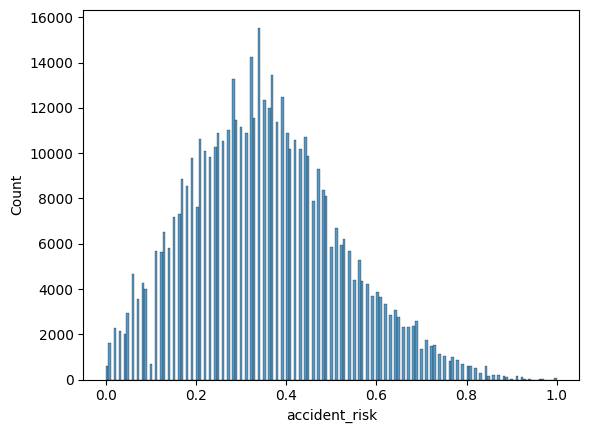

In [9]:
# accident_risk general distribution
sns.histplot(train['accident_risk'])

# Data Preprocessing

## Turn Regression Problem Into Classification Problem
- Idea is to split the accident_risk into two categories:
  - Low risk
  - High risk

In [10]:
# risk_level converting accident_risk values >= 0.5  as true (1) and the rest false (0)
train['risk_level'] = (train['accident_risk'] >= 0.5).astype(int)
# For plotting, 0 = Low Risk, 1 = High Risk
train['risk_label'] = train['risk_level'].map({0: 'Low Risk', 1: 'High Risk'})

In [11]:
train['risk_label'].value_counts() # Raw counts to check for class imbalance

risk_label
Low Risk     420711
High Risk     97043
Name: count, dtype: int64

In [12]:
print(train['risk_label'].value_counts(normalize=True)) # Proportions

risk_label
Low Risk     0.812569
High Risk    0.187431
Name: proportion, dtype: float64


In [13]:
## Assign colors for plotting (Low Risk - Blue, High Risk - Red)
palette = {
    'Low Risk': '#94D4F2',   
    'High Risk': '#FC5151'   
}

# Exploratory Data Analysis

## Numerical Features
- speed_limit (discrete ordinal)
- curvature (continuous)
- num_lanes (discrete ordinal)
- num_reported_accidents (discrete count)

### Check Discrete Values

In [14]:
train['num_lanes'].unique()

array([2, 4, 1, 3])

In [15]:
train['num_reported_accidents'].unique()

array([1, 0, 2, 3, 4, 5, 6, 7])

In [16]:
train['speed_limit'].unique()

array([35, 70, 60, 45, 25])

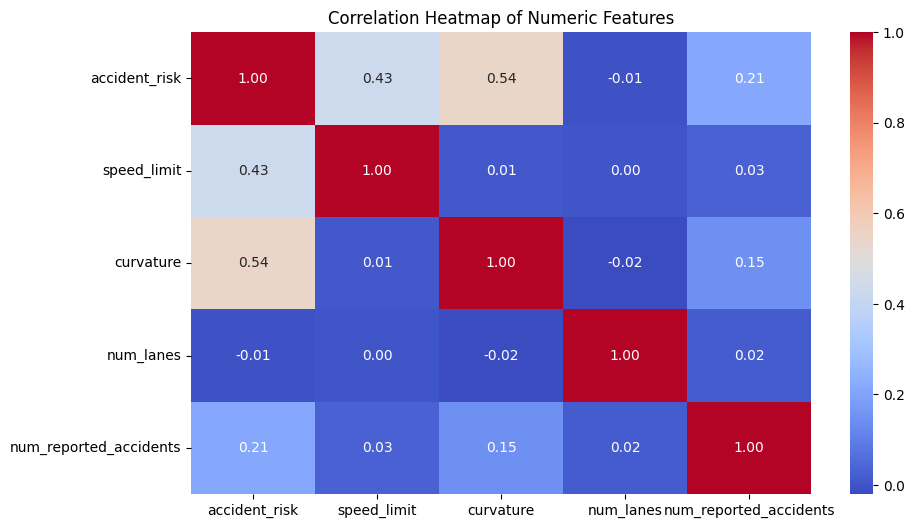

In [17]:
## Check correlation of numeric features
corr = train[['accident_risk', 'speed_limit', 'curvature', 'num_lanes', 'num_reported_accidents']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

### Correlation Heatmap Conclusions
- accident_risk has the highest correlation with speed_limit and curvature, where roads with higher speed limit and curvature tend to have higher accident risk. 
- num_lanes has very little to no correlation with accident_risk, which suggests that num_lanes is unlikely to be a strong predictor. This feature also has no correlation with speed_limit and curvature.
- num_reported_accidents has weak positive relationships with accident_risk and curvature, suggesting that a greater number of reports of accidents is associated with higher accident_risk curvature.

** Caveat: Discrete features may not be suitable to plot in a correlation heatmap, so further plotting will be done seperately.

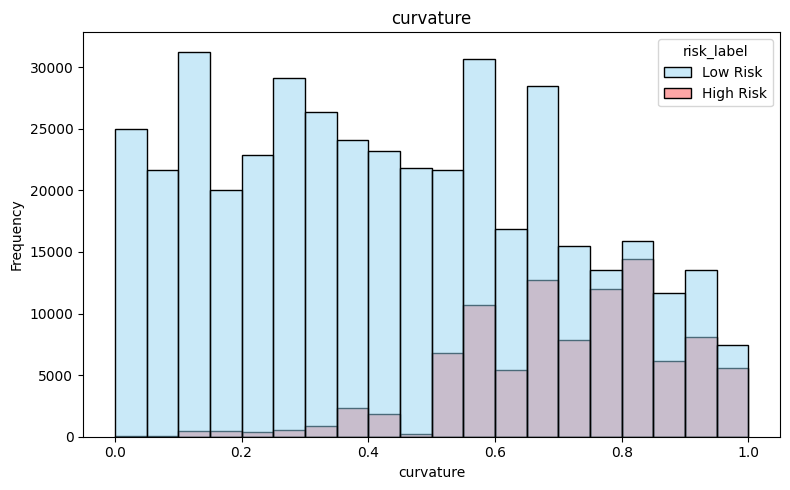

In [18]:
# Histogram of curvature distribution by risk label (continuous feature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=train,
    x='curvature',
    hue='risk_label',
    bins=20,
    multiple='layer',   
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.set_title('curvature')
ax.set_xlabel('curvature')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

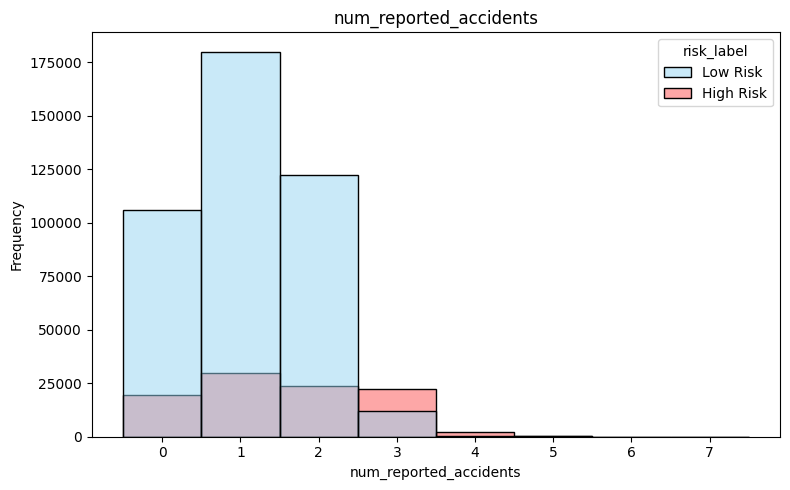

In [19]:
# Histogram of num_reported_accidents distribution by risk label (discrete count feature)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=train,
    x='num_reported_accidents',
    hue='risk_label',
    bins=train['num_reported_accidents'].nunique(),
    discrete=True,           
    multiple='layer',
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.set_title('num_reported_accidents')
ax.set_xlabel('num_reported_accidents')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

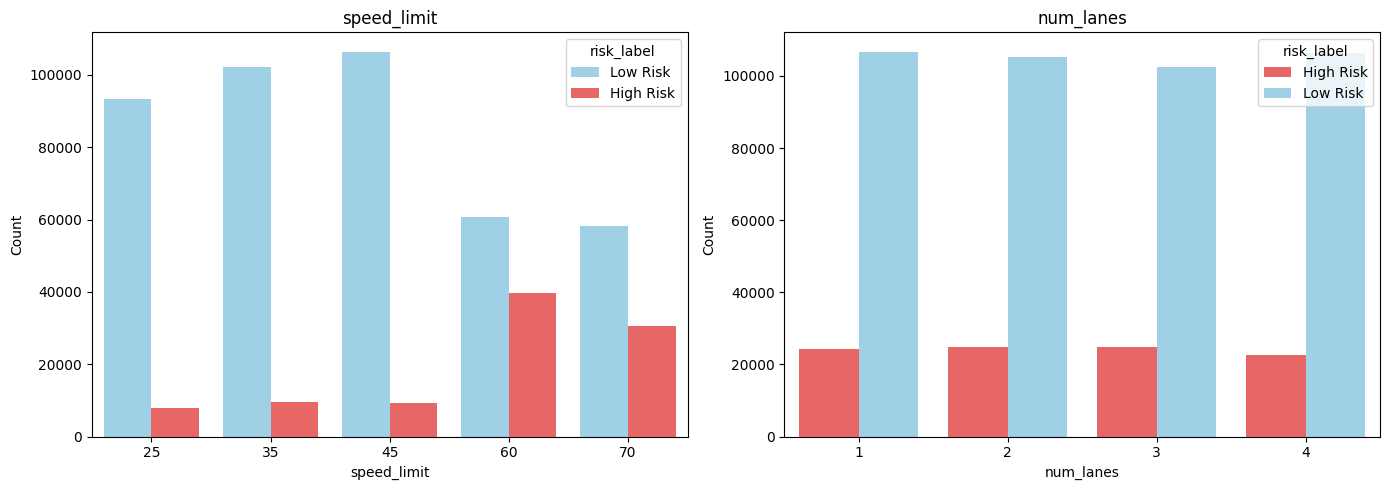

In [20]:
# Histogram of speed_limit and num_lanes distributions by risk label (discrete ordinal features)
ordinal_features = ['speed_limit', 'num_lanes']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(ordinal_features):
    sns.countplot(
        data=train,
        x=col,
        hue='risk_label',
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

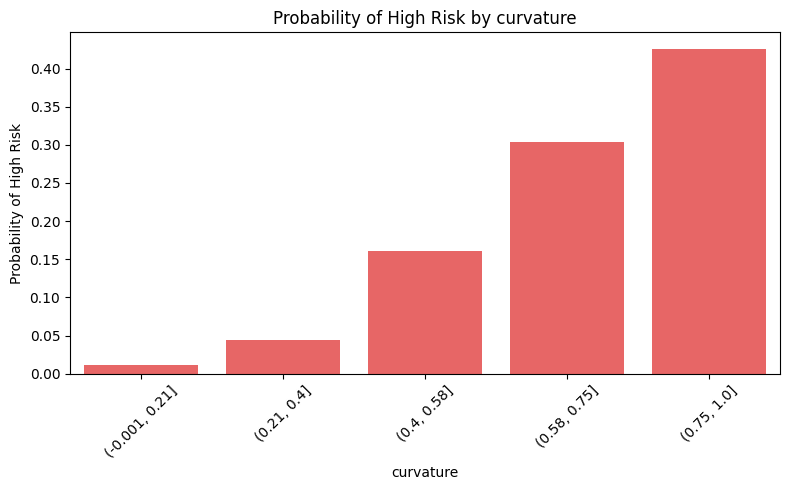

In [21]:
## Probability of High Risk of Curvature
fig, ax = plt.subplots(figsize=(8, 5))
train['curvature_bin'] = pd.qcut(train['curvature'], q=5, duplicates='drop')
prob_df = (
    train.groupby('curvature_bin', observed=True)['risk_level']
    .mean()
    .reset_index(name='prob_high_risk')
)
sns.barplot(data=prob_df, x='curvature_bin', y='prob_high_risk', color='#FC5151', ax=ax)
ax.set_title('Probability of High Risk by curvature')
ax.set_xlabel('curvature')
ax.set_ylabel('Probability of High Risk')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

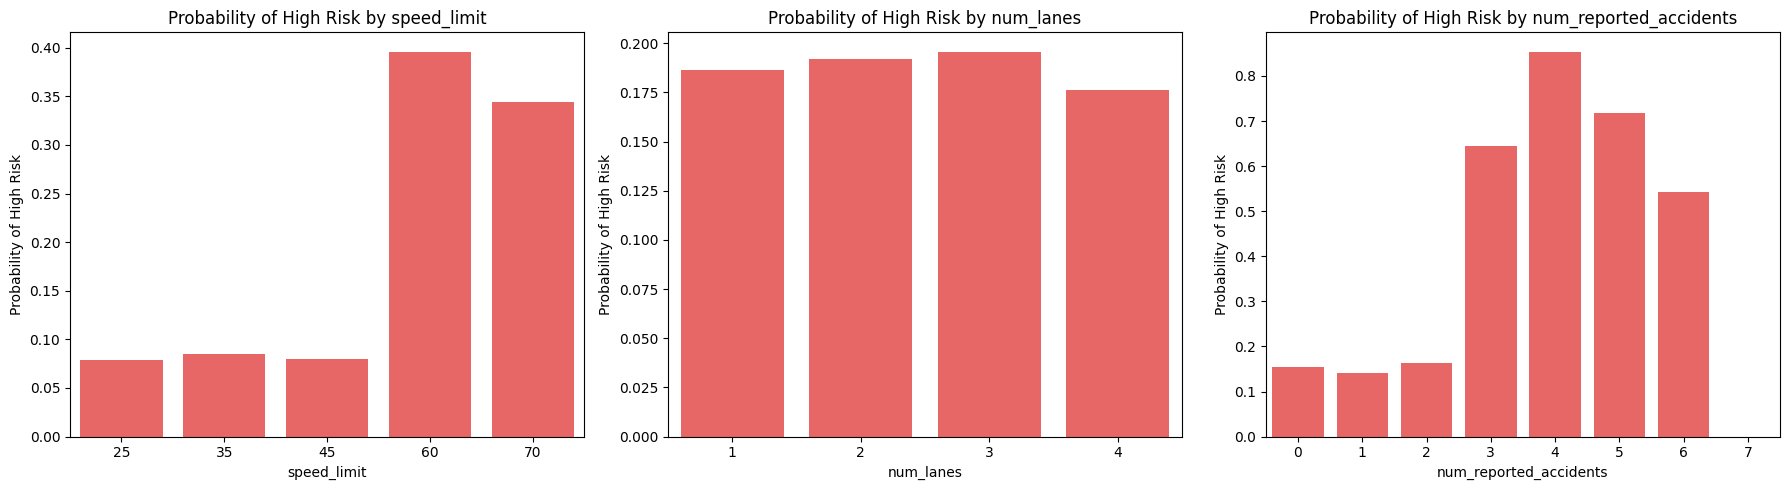

In [22]:
## Probability of High Risk of Discrete Features
raw_features = ['speed_limit', 'num_lanes', 'num_reported_accidents']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(raw_features):
    prob_df = (
        train.groupby(col, observed=True)['risk_level']
        .mean()
        .reset_index(name='prob_high_risk')
    )
    sns.barplot(
        data=prob_df,
        x=col,
        y='prob_high_risk',
        color='#FC5151',
        ax=axes[i]
    )
    axes[i].set_title(f'Probability of High Risk by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Probability of High Risk')
plt.tight_layout()
plt.show()

In [23]:
## Probability of High Risk in Tables
num_tables = {}
overall_prob = train['risk_level'].mean()

continuous = ['curvature']
discrete = ['speed_limit', 'num_lanes', 'num_reported_accidents']

for num in continuous:
    bins = pd.qcut(train[num], q=5, duplicates='drop')
    num_prob = train.groupby(bins, observed=True)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    # prob_difference: the difference between the probability of High Risk for a specific bin compared to the 
    # probability of High Risk for the entire dataset
    # - Positive prob_difference indicates higher risk than average
    # - Negative prob_difference indicates lower risk than average
    num_prob['prob_difference'] = num_prob['probability'] - overall_prob
    num_tables[num] = num_prob

for num in discrete:
    num_prob = train.groupby(train[num], observed=True)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    num_prob['prob_difference'] = num_prob['probability'] - overall_prob
    num_tables[num] = num_prob

In [24]:
for num in continuous:
    styled = num_tables[num].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {num}")

    display(styled)

,count,probability,prob_difference
curvature,,,
"(-0.001, 0.21]","108,383",0.012,-0.176
"(0.21, 0.4]","104,102",0.044,-0.144
"(0.4, 0.58]","98,586",0.161,-0.026
"(0.58, 0.75]","104,433",0.304,+0.116
"(0.75, 1.0]","102,250",0.426,+0.239


In [25]:
for num in discrete:
    styled = num_tables[num].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {num}")

    display(styled)

,count,probability,prob_difference
speed_limit,,,
25,"101,422",0.079,-0.108
35,"111,628",0.085,-0.103
45,"115,752",0.080,-0.107
60,"100,304",0.396,+0.209
70,"88,648",0.345,+0.157


,count,probability,prob_difference
num_lanes,,,
1,"131,168",0.186,-0.001
2,"130,054",0.192,+0.004
3,"127,414",0.196,+0.008
4,"129,118",0.176,-0.011


,count,probability,prob_difference
num_reported_accidents,,,
0,"125,269",0.154,-0.033
1,"209,674",0.141,-0.046
2,"145,965",0.163,-0.024
3,"34,197",0.644,+0.457
4,"2,392",0.854,+0.667
5,231,0.719,+0.531
6,24,0.542,+0.354
7,2,0.000,-0.187


### Numerical Feature Findings
From the correlation heatmap, distribution plots, and probability tables:
- curvature was the strongest predictor, showing a clear increase in accident risk across the probability bins from low to high curvature.
- speed_limit showed a substantial increase in accident_risk with roads at 60mph and over compared to slower roads at 45mph and below.
- num_reported_accidents showed a sharp jump at 3 or more accidents, with values 0-2 showing little variation in risk.
- num_lanes showed very little variation in risk across all values, so it is appropriate to exclude this feature from modeling

## Categorical Features
- road_type
- lighting
- weather
- road_signs_present
- public_road
- time_of_day
- holiday
- school_season

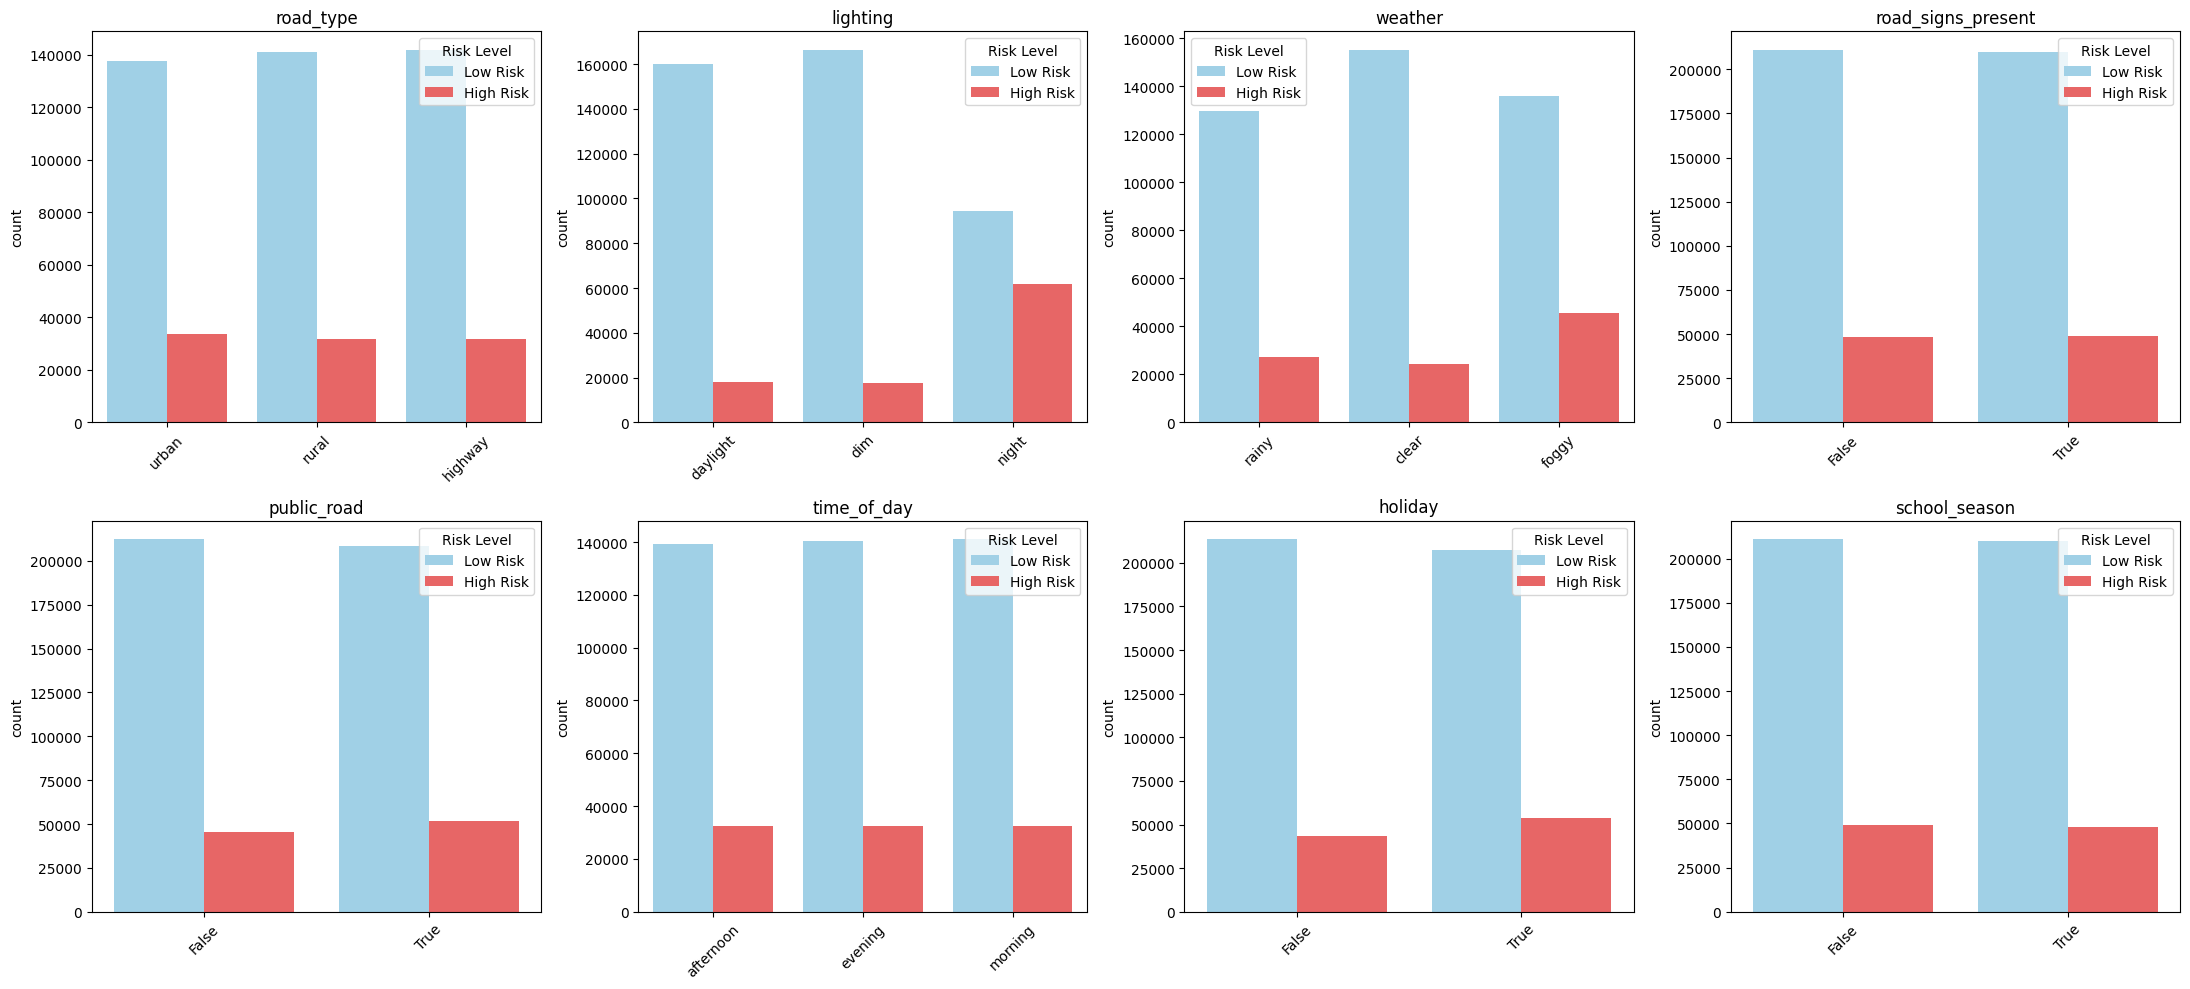

In [26]:
## Countplots of Low and High Risk for each categorical variable
cat_features = ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']  

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, cat in enumerate(cat_features):
    sns.countplot(data=train, x=cat, hue='risk_label', ax=axes[i], palette=palette)
    axes[i].set_title(cat)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title="Risk Level")
    
plt.tight_layout()
plt.show()

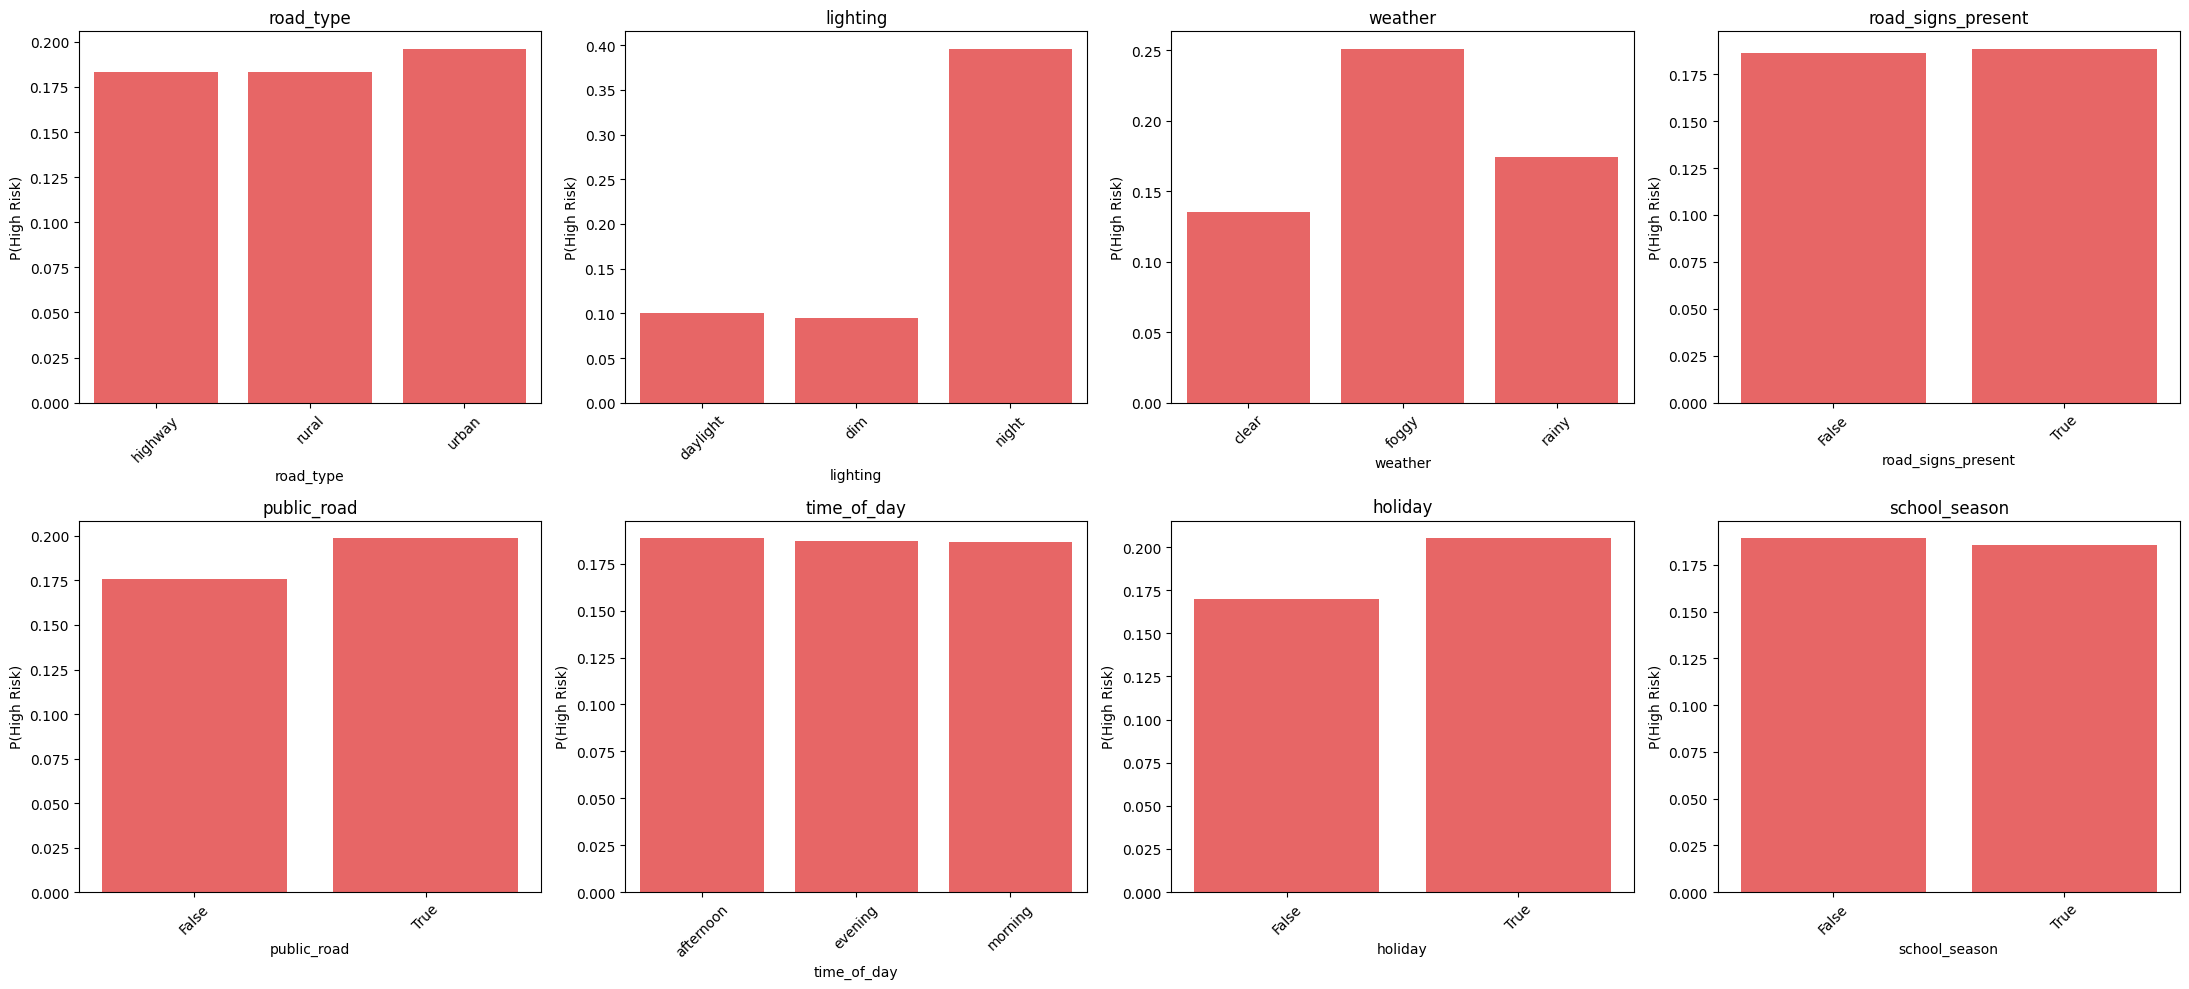

In [27]:
## Probability of High Risk for each categorical variable

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, cat in enumerate(cat_features):

    prob_df = (
        train.groupby(cat, observed=True)['risk_level']
        .mean()
        .reset_index(name='prob_high_risk')
    )

    sns.barplot(
        data=prob_df,
        x=cat,
        y='prob_high_risk',
        ax=axes[i],
        color='#FC5151'
    )

    axes[i].set_title(cat)
    axes[i].set_ylabel('P(High Risk)')
    axes[i].set_xlabel(cat)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [28]:
## Probability of High Risk for each categorical variable in tables

cat_tables = {}

overall_prob = train['risk_level'].mean()

for cat in cat_features:
    cat_prob = train.groupby(cat)['risk_level'].agg(
        count='count',
        probability='mean'
    )
    
    cat_prob['prob_difference'] = cat_prob['probability'] - overall_prob
    
    cat_tables[cat] = cat_prob

In [29]:
for cat in cat_features:
    styled = cat_tables[cat].style.format({
        'count': '{:,.0f}',
        'probability': '{:.3f}',
        'prob_difference': '{:+.3f}'
    }).set_caption(f"Risk Summary: {cat}")

    display(styled)

,count,probability,prob_difference
road_type,,,
highway,"173,672",0.183,-0.004
rural,"172,719",0.183,-0.004
urban,"171,363",0.196,+0.009


,count,probability,prob_difference
lighting,,,
daylight,"178,015",0.100,-0.087
dim,"183,826",0.095,-0.092
night,"155,913",0.396,+0.208


,count,probability,prob_difference
weather,,,
clear,"179,306",0.135,-0.052
foggy,"181,463",0.251,+0.063
rainy,"156,985",0.174,-0.013


,count,probability,prob_difference
road_signs_present,,,
False,"259,289",0.186,-0.001
True,"258,465",0.188,+0.001


,count,probability,prob_difference
public_road,,,
False,"257,709",0.176,-0.011
True,"260,045",0.199,+0.011


,count,probability,prob_difference
time_of_day,,,
afternoon,"171,507",0.188,+0.001
evening,"172,837",0.187,-0.000
morning,"173,410",0.187,-0.001


,count,probability,prob_difference
holiday,,,
False,"257,066",0.170,-0.018
True,"260,688",0.205,+0.018


,count,probability,prob_difference
school_season,,,
False,"260,164",0.189,+0.002
True,"257,590",0.186,-0.002


### Categorical Feature Findings
From the count plots and probability tables:
- road_type, road_signs_present, public_road, time_of_day, and school_season all showed very little variation in accident risk and will be excluded from modeling.
- holiday showed some variation, but was ultimately insufficient to justify inclusion given its weak signal.
- lighting is a strong predictor, with night conditions showing substantially higher accident risk compared to daylight and dim conditions.
- weather is a moderate predictor, with foggy conditions associated with higher accident risk, compared to clear and rainy conditions. Rainy conditions showed a prob_difference of only -0.013, which is surprisingly similar to clear conditions.

## EDA Conclusion
Based on the correlation heatmap, distribution plots, and probability tables, 
the most informative variables for predicting accident risk are curvature, 
speed_limit, num_reported_accidents, weather, and lighting. Features such as 
num_lanes, road_type, road_signs_present, public_road, time_of_day, holiday, 
and school_season showed very little variation in accident risk and were 
excluded from modelling.

# Feature Engineering

## Preprocessing Measures Taken For Both Train and Test Datasets
1. Reloaded raw dataset and reapplied binarization of accident_risk
3. Binarization of speed_limit and num_reported accidents
    - is_highway created since EDA showed a sharp risk increase at 60mph and above
       - <60 = 0 (Low Risk), >=60 = 1 (High Risk)
    - is_accident_prone created since EDA showed a sharp risk increase at 3 or more accidents
       - <3 = 0 (Low Risk), >=3 = 1 (High Risk)
4. One-Hot Encoding for the two categorical features, weather and lighting
5. Created 4 interaction terms
   - speed_x_curvature: combines speed_limit and curvature
   - night_x_curvature: combines lighting_night and curvature
   - highway_x_night: combines is_highway and lighting_night
   - fog_x_highway: combines weather_foggy and is_highway

In [30]:
# Reload raw data
train = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/train.csv')
test = pd.read_csv('/Users/tanvirsingh/Downloads/playground-series-s5e10/test.csv')

# Convert continuous accident_risk to binary classification target
train['risk_level'] = (train['accident_risk'] >= 0.5).astype(int)
train['risk_label'] = train['risk_level'].map({0: 'Low Risk', 1: 'High Risk'})

In [31]:
# Feature Engineering Applied to both Train and Test
for df in [train, test]:
    ## Binarization of speed_limit and num_reported_accidents
    df['is_highway'] = (df['speed_limit'] >= 60).astype(int)
    df['is_accident_prone'] = (df['num_reported_accidents'] >= 3).astype(int)

    ## One-Hot Encoding of categorical features
    df['lighting'] = df['lighting'].str.lower()
    df['weather'] = df['weather'].str.lower()
train = pd.get_dummies(train, columns=['lighting', 'weather'], drop_first=True)
test = pd.get_dummies(test, columns=['lighting', 'weather'], drop_first=True)

for df in [train, test]:
    ## Interaction terms
    df['speed_x_curvature'] = df['speed_limit'] * df['curvature']
    df['night_x_curvature'] = df['lighting_night'] * df['curvature']
    df['highway_x_night'] = df['is_highway'] * df['lighting_night']
    df['fog_x_highway'] = df['weather_foggy'] * df['is_highway']

In [59]:
# Feature cols definition
feature_cols = [
    'curvature', 'speed_limit', 'num_reported_accidents',
    'is_highway', 'is_accident_prone',
    'lighting_dim', 'lighting_night',
    'weather_foggy', 'weather_rainy',
    'speed_x_curvature', 'night_x_curvature',
    'highway_x_night', 'fog_x_highway'
]

# Split train
X = train[feature_cols]
y = train['risk_level']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Test
X_test = test[feature_cols]

# Machine Learning
- Logistic Regression
- Decision Tree
- Random Forest

## Logistic Regression (Accuracy 0.91; Best Model Overall)

In [66]:
# Feature scaling for log reg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [67]:
lr = LogisticRegression(
    class_weight='balanced', # class weighing applied to address class imbalance
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [70]:
y_pred = lr.predict(X_val_scaled)
y_prob = lr.predict_proba(X_val_scaled)[:, 1]

In [71]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94     84142
           1       0.70      0.93      0.80     19409

    accuracy                           0.91    103551
   macro avg       0.84      0.92      0.87    103551
weighted avg       0.93      0.91      0.92    103551



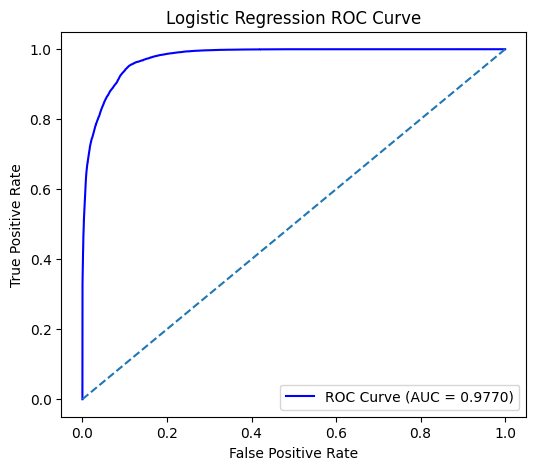

In [83]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')

plt.show()

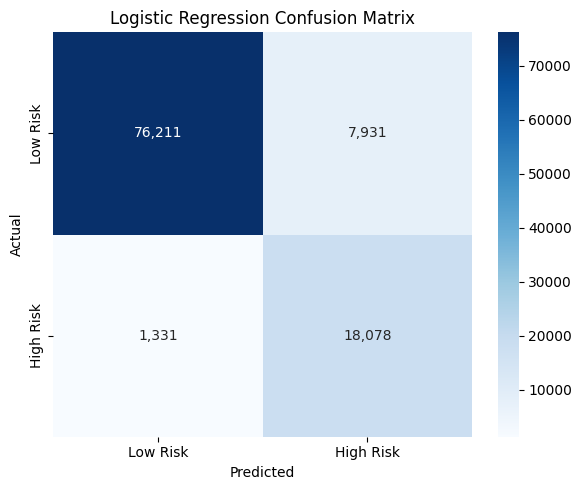

In [84]:
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Logistic Regression Findings:
- AUC-ROC is 0.9770, meaning that Logistic Regression is very good at distinguishing between low and high risk roads.
  
- Class 0 (Low Risk): Precision is 0.98 and recall is 0.91, meaning the model is very accurate when predicting low risk roads and catches most actual low risk cases.
  
- Class 1 (High Risk): Recall is 0.93, meaning that the model catches 93% of actually high risk roads, which is the most important metric for a road safety problem. Precision of 0.70 means 30% of roads predicted as high risk are actually low risk, which shows some false alarms but acceptable given the high recall. It is better for the model to read more false positives rather than having many high risk roads read as low risk.


## Decision Tree (Accuracy 0.91)

In [76]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [77]:
y_pred_dt = dt.predict(X_val)
y_prob_dt = dt.predict_proba(X_val)[:, 1]

In [78]:
print(classification_report(y_val, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     84142
           1       0.68      0.94      0.79     19409

    accuracy                           0.91    103551
   macro avg       0.83      0.92      0.87    103551
weighted avg       0.93      0.91      0.91    103551



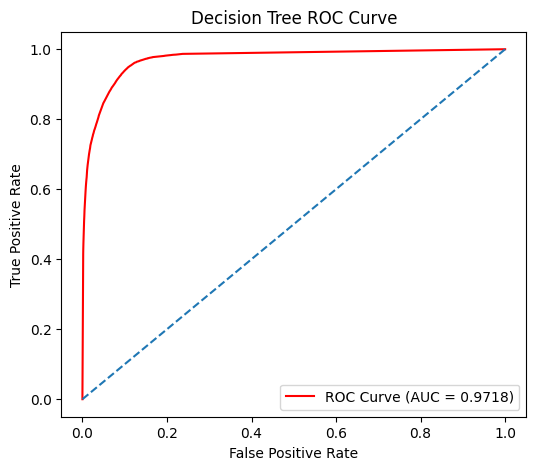

In [85]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_dt)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='red', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')

plt.show()

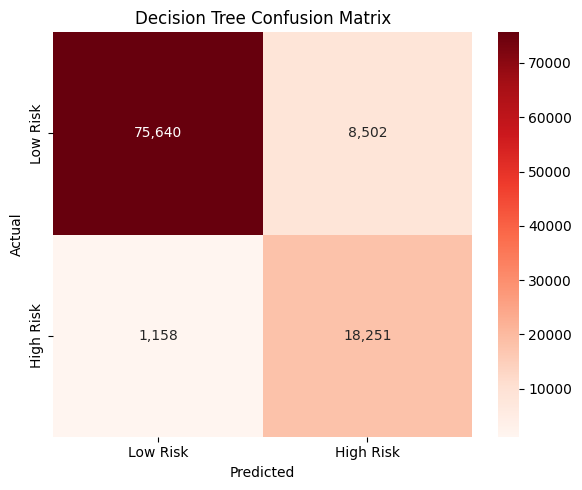

In [86]:
cm_dt = confusion_matrix(y_val, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=',',
    cmap='Reds',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Decision Tree Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Decision Tree Findings:
- AUC-ROC is 0.9718, which is lower than Logistic Regression, meaning that the Decision Tree model is less precise at distinguishing between low and high risk roads compared to Logistic Regression.
  
- Class 0 (Low Risk): Precision is 0.98 and recall is 0.90, meaning that when the model predicts a road is low risk, it is almost always correct, and it correctly identifies most actual low risk roads. Compared to Logistic Regression, this model achieves higher precision but slightly lower recall for this class.

- Class 1 (High Risk): Precision is 0.68 and recall is 0.94, meaning that this model is similar to Logistic Regression, where it predicts more high risk roads compared to low risk, but only 68% of those roads are actually high risk, which is less than the 70% from Logistic Regression. 

## Random Forest (Accuracy 0.91)

In [79]:
rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [80]:
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

In [81]:
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     84142
           1       0.69      0.93      0.79     19409

    accuracy                           0.91    103551
   macro avg       0.84      0.92      0.87    103551
weighted avg       0.93      0.91      0.91    103551



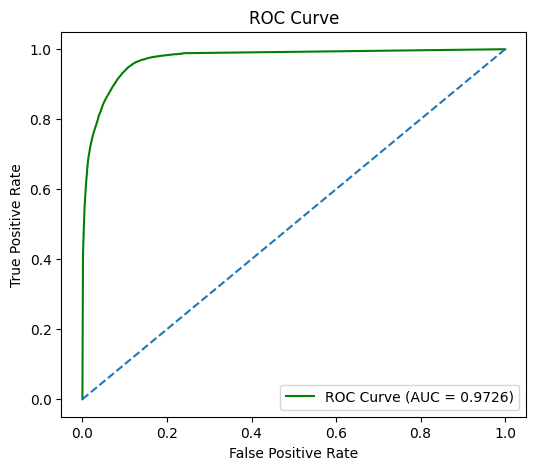

In [87]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_rf)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')  

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

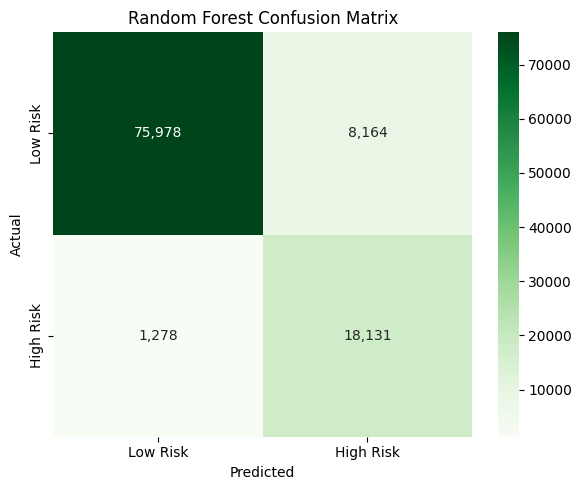

In [88]:
cm_rf = confusion_matrix(y_val, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt=',',
    cmap='Greens',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax
)
ax.set_title('Random Forest Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Random Forest Findings:
- AUC-ROC is 0.9726, which is higher than the Decision Tree model, but lower than Logistic Regression model.
  
- Class 0 (Low Risk): Precision is 0.98 and recall is 0.90, which is the same as the Decision Tree model.

- Class 1 (High Risk): Precision is 0.69 and recall is 0.93, which very close to the Decision Tree model

- A model like Random Forest, which uses multiple decision trees to identify more complex, nonlinear patterns within the dataset, produced very similar results to the Decision Tree model (except with the AUC, where it is slightly higher than the Decision Tree model). This suggests that using a more complex model does not significantly improve predictive performance for this dataset

# Conclusion
- Logistic Regression, Decision Tree, and Random Forest all had very similar results and all had an accuracy of 0.91, but in terms of the differing AUC values across all three models, the Logistic Regression model showed the best overall performance as it had the highest AUC of 0.9770.
  
- Even though the Decision Tree model had the least amount of false negatives according to the confusion matrices, it also yielded the most false positives by a substantial amount, highlighting a trade off toward increased sensitivity at the expense of precision. This can indicate overfitting in the model and produce less stable decision boundaries compared to Logistic Regression and Random Forest. 

In [89]:
X = train[feature_cols]
y = train['risk_level']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_final = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_final.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [90]:
X_test = test[feature_cols]
X_test_scaled = scaler.transform(X_test)

In [92]:
test_preds = lr_final.predict(X_test_scaled)

test['predicted_risk'] = test_preds
test['predicted_risk_label'] = test['predicted_risk'].map({
    0: 'Low Risk',
    1: 'High Risk'
})

In [97]:
submission = pd.DataFrame({
    'id': test['id'],
    'risk_prediction': test['predicted_risk_label']
})

display(submission.head())

,id,risk_prediction
0,517754,Low Risk
1,517755,Low Risk
2,517756,Low Risk
3,517757,Low Risk
4,517758,Low Risk


In [99]:
test_output = test[['predicted_risk_label']]
print(test_output.value_counts())

predicted_risk_label
Low Risk                129350
High Risk                43235
Name: count, dtype: int64
